In [1]:
!pip install -q lightgbm catboost xgboost plotly seaborn joblib

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
file_path = "final_selected_features.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (12469, 19)


,Academic_Engagement,Assignment_Attendance_Index,Study_Assignment_Index,Study_Attendance_Index,AssignmentCompletion,Attendance_Normalized,Age,Attendance,StudyHours,OnlineCourses,StudyHours_Normalized,LearningStyle,Motivation_Study_Index,StressLevel,Online_Learning_Activity,Participation_Rate,Digital_Learning_Index,Motivation,FinalGrade
0,61.436364,37.76,0.254773,0.276364,59,0.64,19,64,19,8,0.431818,2,0.0,1,8,0.5,0.46,0,3
1,63.836364,57.60,0.388636,0.276364,90,0.64,23,64,19,16,0.431818,3,0.0,1,16,0.0,0.62,0,2
2,54.636364,42.88,0.289318,0.276364,67,0.64,28,64,19,19,0.431818,1,0.0,1,38,0.0,0.88,0,0
3,61.436364,37.76,0.254773,0.276364,59,0.64,19,64,19,8,0.431818,2,0.0,1,8,1.0,0.46,0,3
4,63.836364,57.60,0.388636,0.276364,90,0.64,23,64,19,16,0.431818,3,0.0,1,16,0.5,0.62,0,2


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
for col in df.columns:
    print(col)

print("\nData Types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing Values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate Rows:", df.duplicated().sum())

Rows: 12469
Columns: 19

Column Names:
Academic_Engagement
Assignment_Attendance_Index
Study_Assignment_Index
Study_Attendance_Index
AssignmentCompletion
Attendance_Normalized
Age
Attendance
StudyHours
OnlineCourses
StudyHours_Normalized
LearningStyle
Motivation_Study_Index
StressLevel
Online_Learning_Activity
Participation_Rate
Digital_Learning_Index
Motivation
FinalGrade

Data Types:


,dtype
Academic_Engagement,float64
Assignment_Attendance_Index,float64
Study_Assignment_Index,float64
Study_Attendance_Index,float64
AssignmentCompletion,int64
Attendance_Normalized,float64
Age,int64
Attendance,int64
StudyHours,int64
OnlineCourses,int64



Missing Values:


,missing
Academic_Engagement,0
Assignment_Attendance_Index,0
Study_Assignment_Index,0
Study_Attendance_Index,0
AssignmentCompletion,0
Attendance_Normalized,0
Age,0
Attendance,0
StudyHours,0
OnlineCourses,0



Duplicate Rows: 3


FinalGrade
0    3401
1    2943
2    3221
3    2904
Name: count, dtype: int64


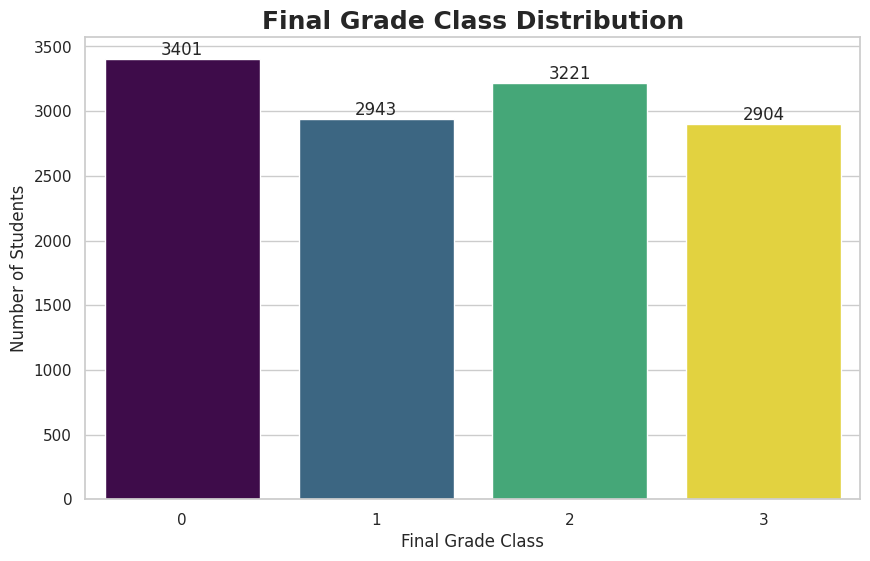

In [5]:
target = "FinalGrade"

print(df[target].value_counts().sort_index())

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x=target,
    hue=target,
    palette="viridis",
    legend=False
)

plt.title("Final Grade Class Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Final Grade Class")
plt.ylabel("Number of Students")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [6]:
target_percentage = (
    df[target]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

display(
    target_percentage
    .round(2)
    .to_frame("Percentage")
)

,Percentage
FinalGrade,
0,27.28
1,23.60
2,25.83
3,23.29


In [7]:
numeric_df = df.select_dtypes(include=np.number)

infinite_values = np.isinf(numeric_df).sum()

print("Total infinite values:", infinite_values.sum())

display(
    infinite_values[infinite_values > 0]
    .to_frame("infinite_values")
)

Total infinite values: 0


,infinite_values


In [8]:
duplicate_columns = []

columns = df.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        if df[columns[i]].equals(df[columns[j]]):
            duplicate_columns.append((columns[i], columns[j]))

print("Duplicate column pairs:")
display(duplicate_columns)

Duplicate column pairs:


[]

In [9]:
constant_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

print("Constant columns:")
print(constant_columns)

Constant columns:
[]


In [10]:
X = df.drop(columns=[target])
y = df[target]

categorical_features = [
    "LearningStyle",
    "StressLevel",
    "Motivation"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Academic_Engagement', 'Assignment_Attendance_Index', 'Study_Assignment_Index', 'Study_Attendance_Index', 'AssignmentCompletion', 'Attendance_Normalized', 'Age', 'Attendance', 'StudyHours', 'OnlineCourses', 'StudyHours_Normalized', 'Motivation_Study_Index', 'Online_Learning_Activity', 'Participation_Rate', 'Digital_Learning_Index']

Categorical Features:
['LearningStyle', 'StressLevel', 'Motivation']


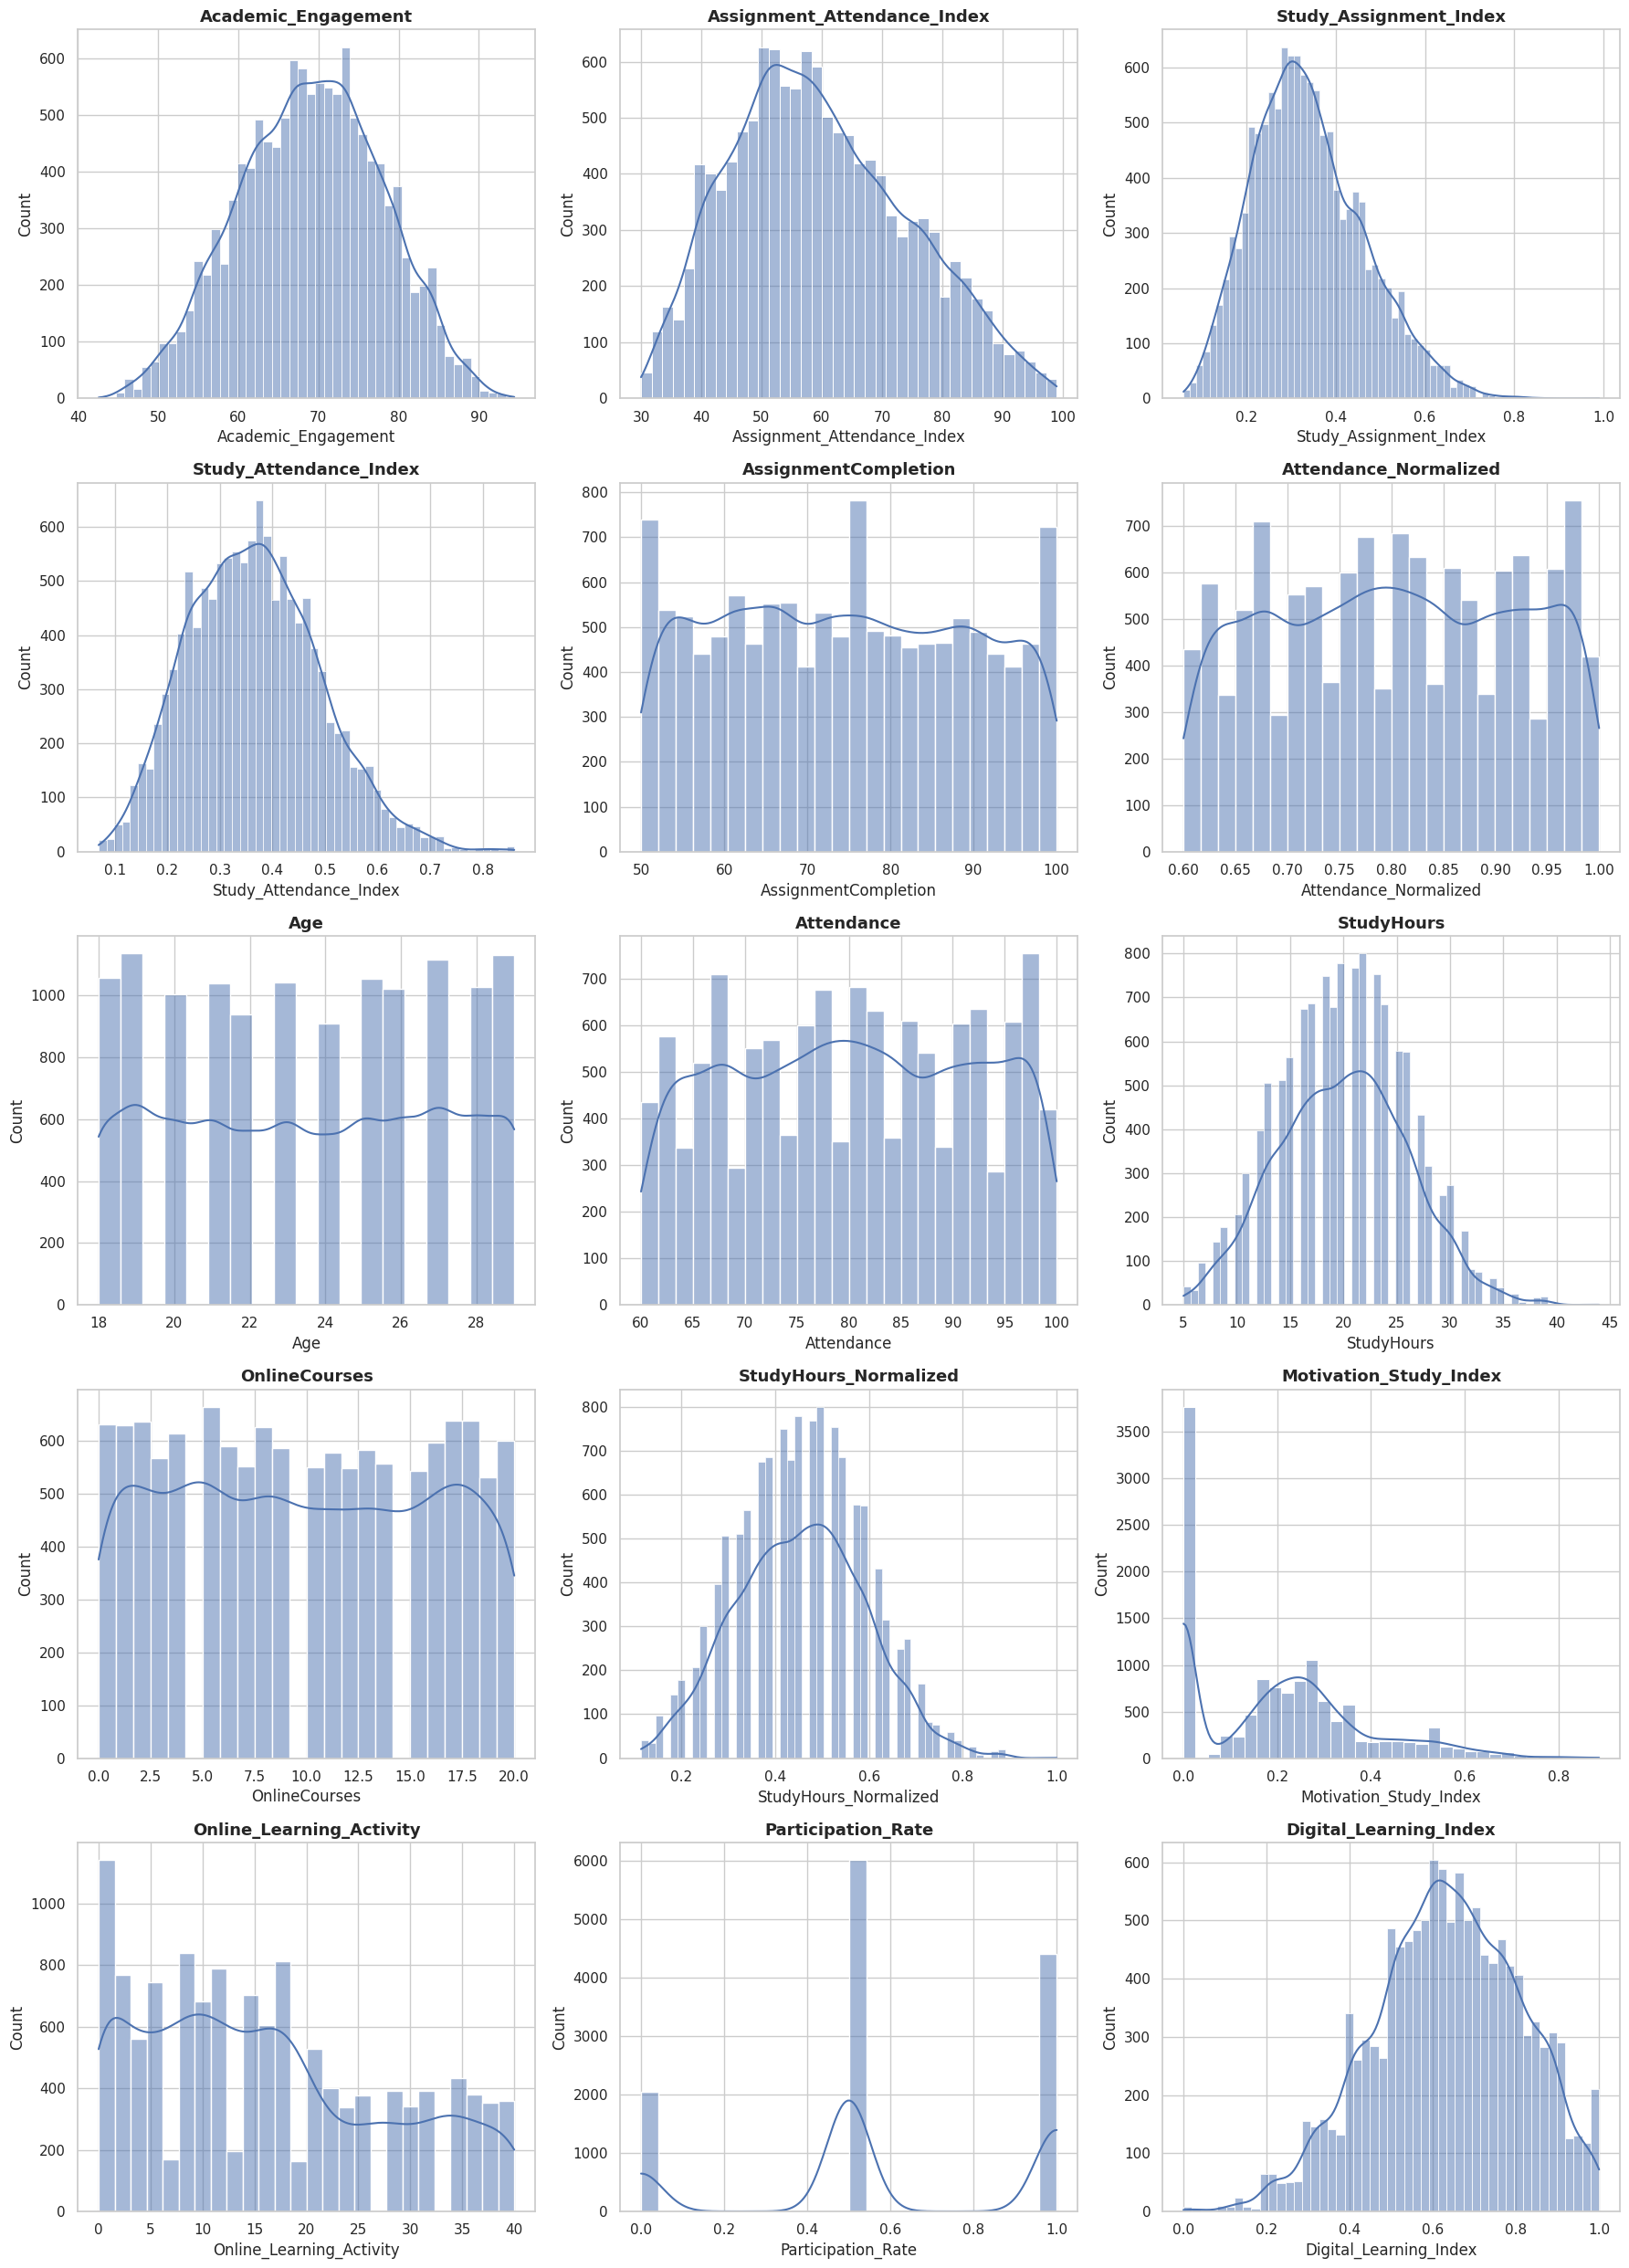

In [11]:
n_cols = 3
n_rows = int(np.ceil(len(numerical_features) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numerical_features):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=ax
    )
    ax.set_title(col, fontsize=13, fontweight="bold")

for ax in axes[len(numerical_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

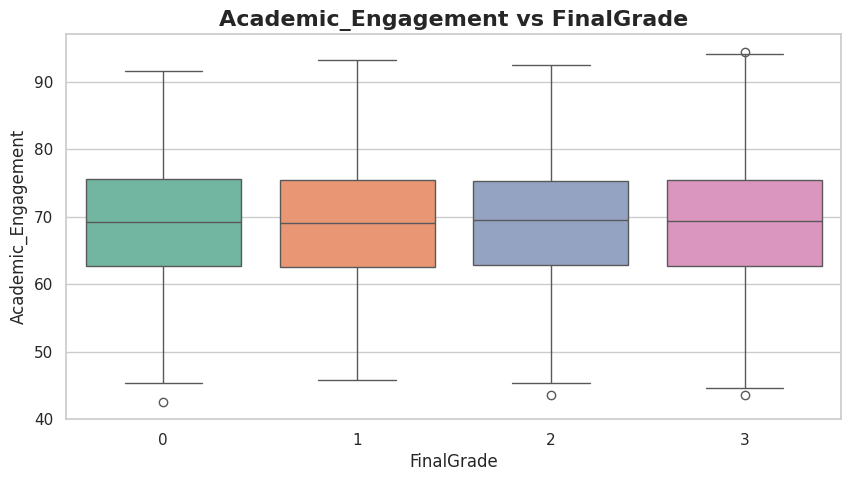

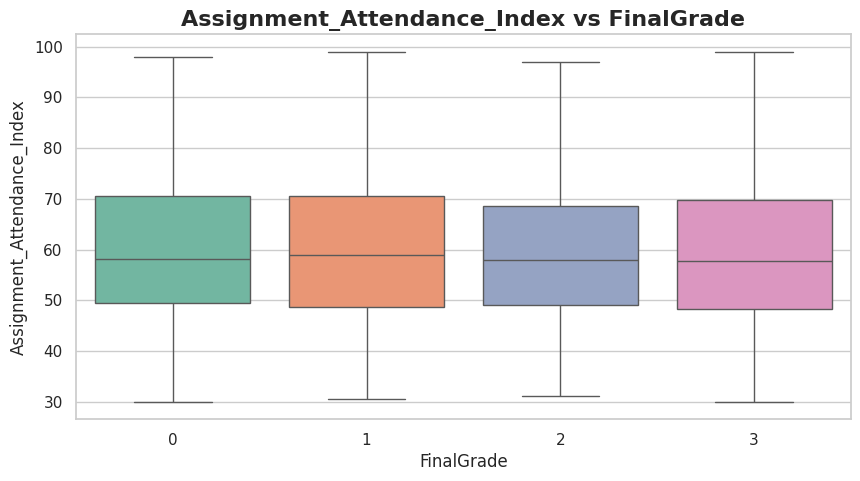

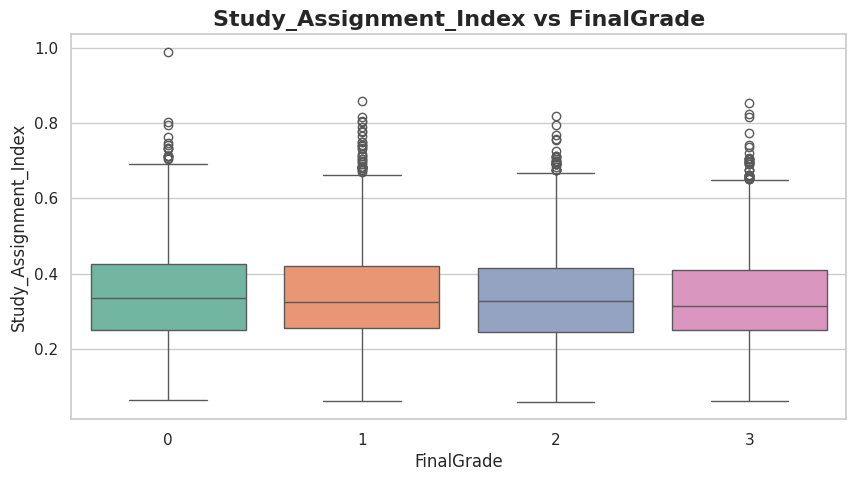

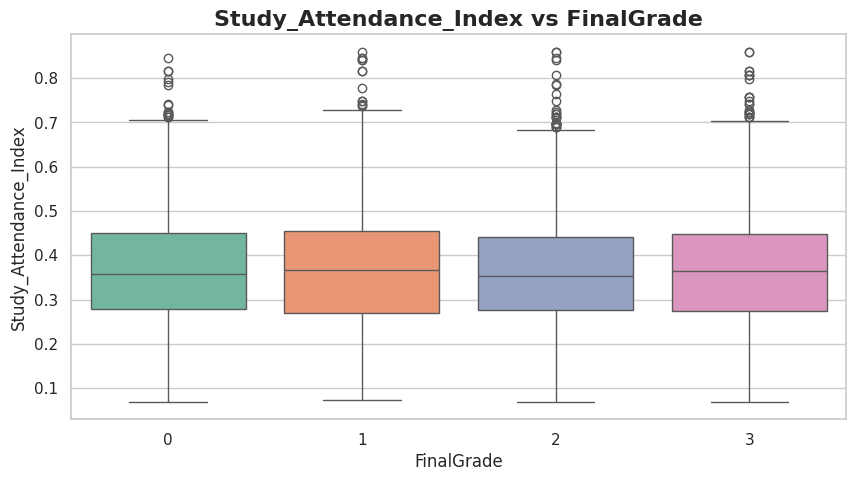

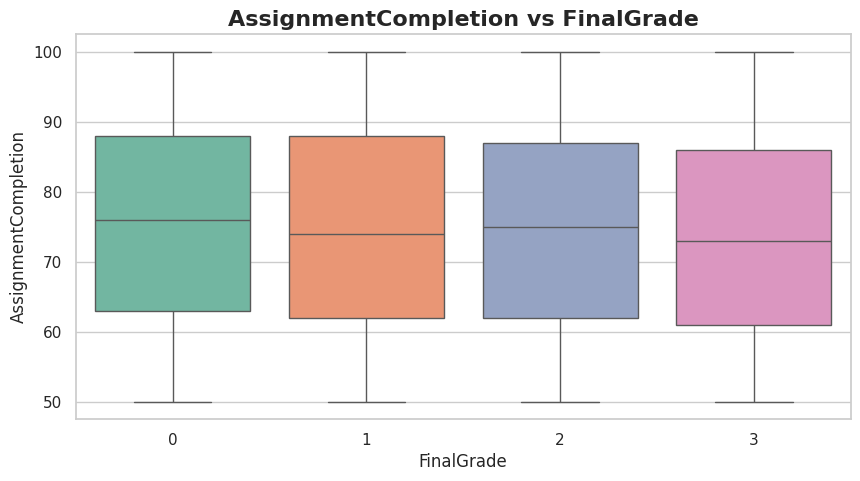

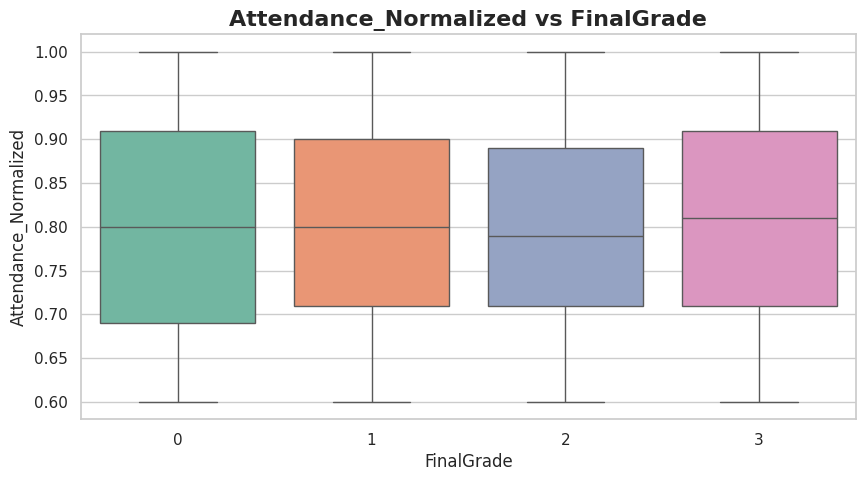

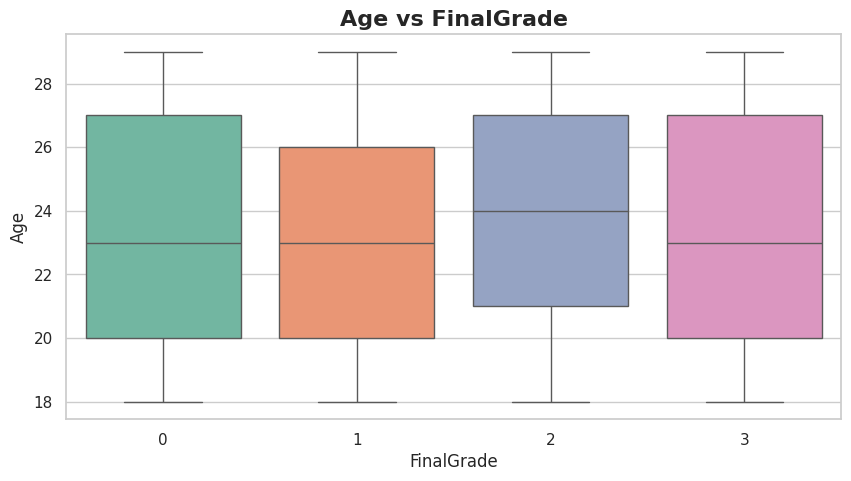

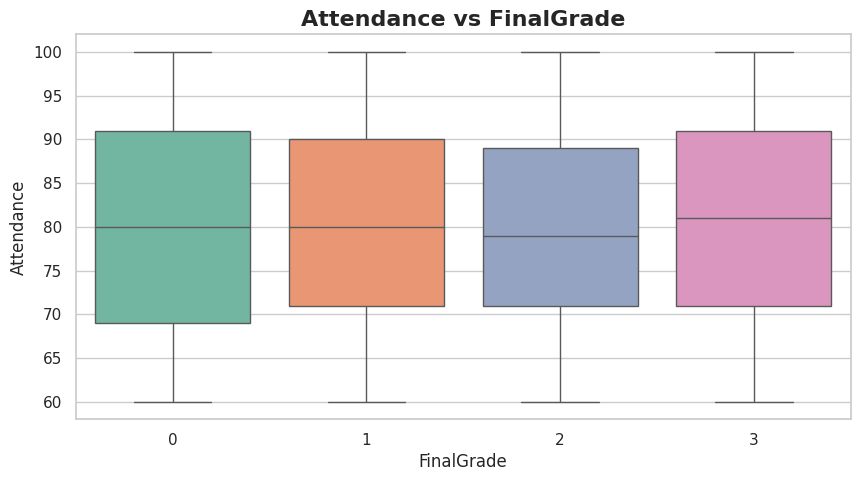

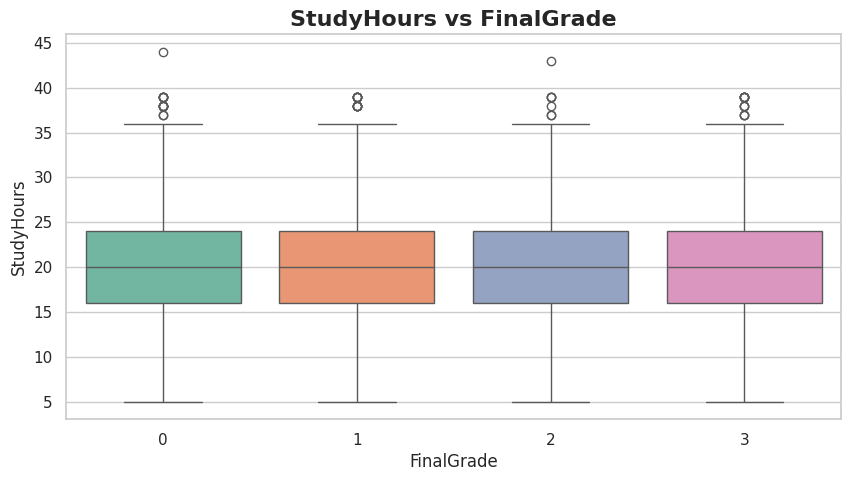

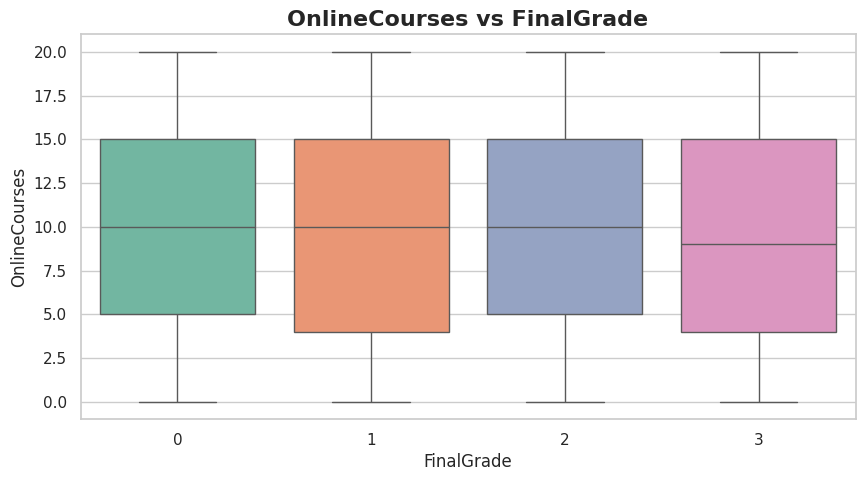

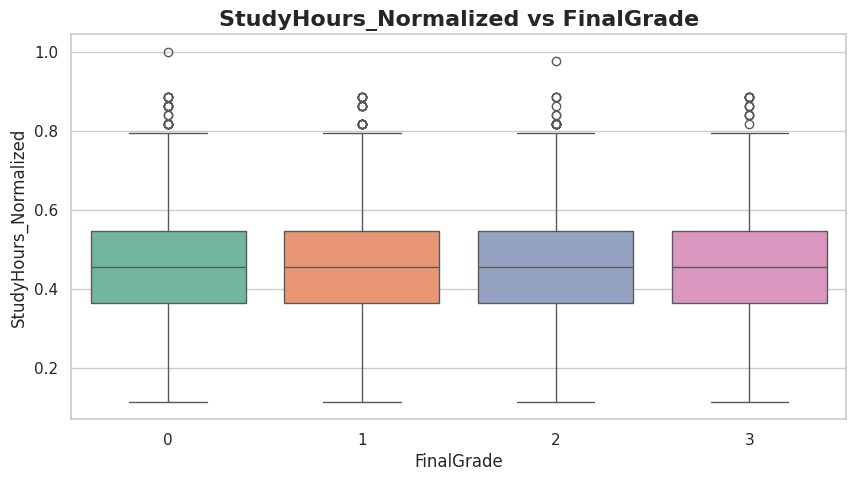

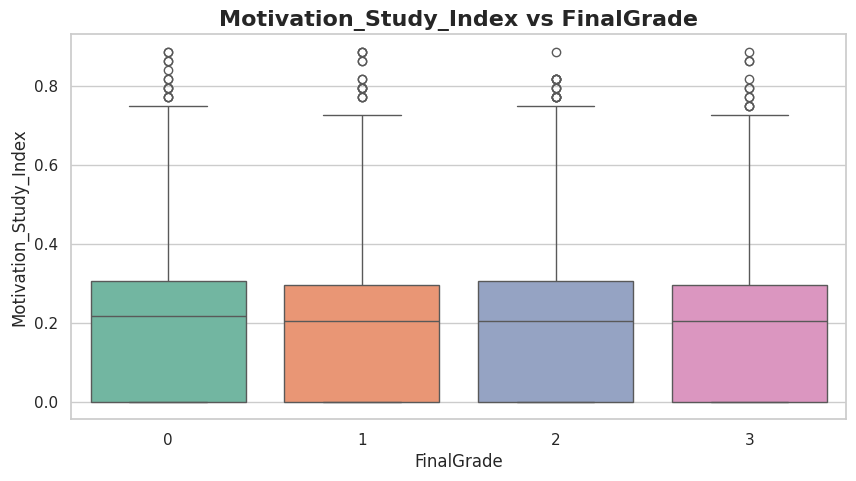

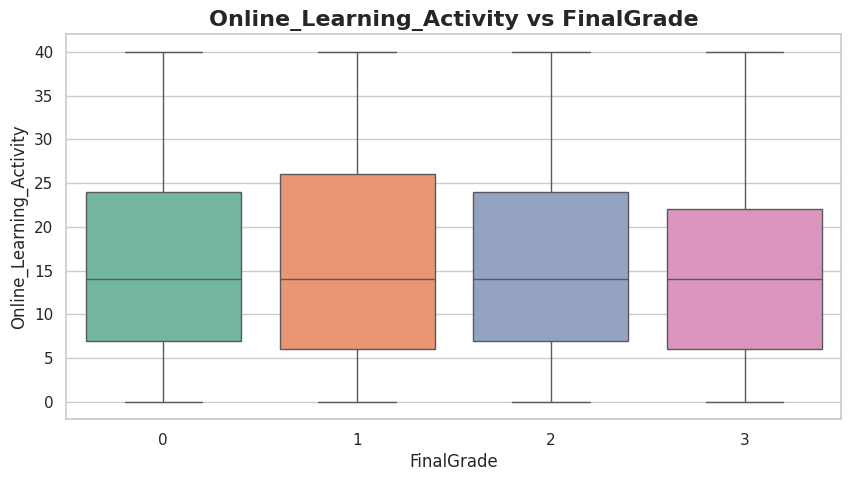

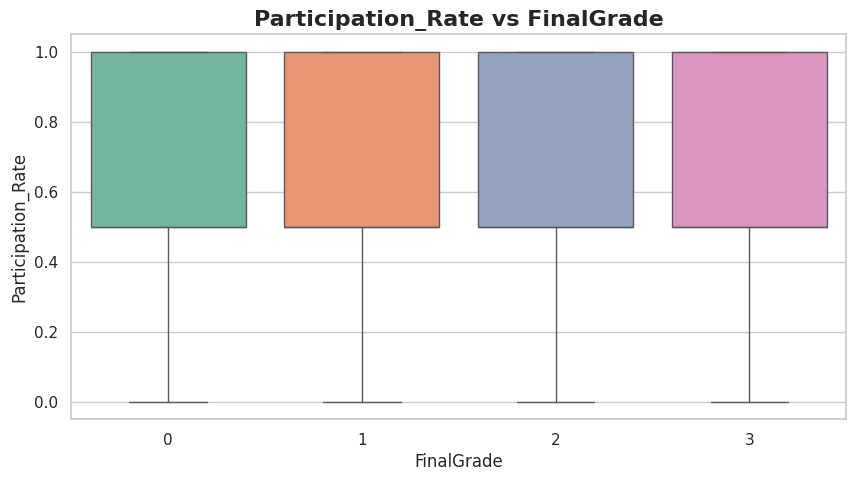

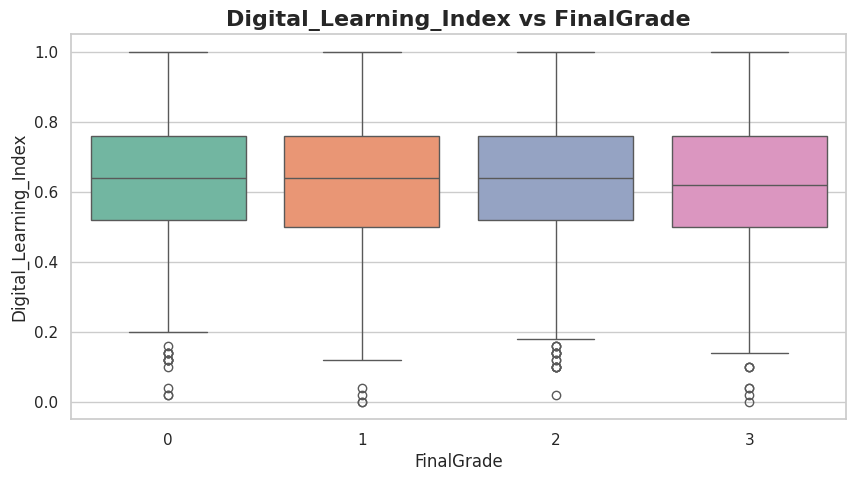

In [12]:
for col in numerical_features:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        data=df,
        x=target,
        y=col,
        hue=target,
        palette="Set2",
        legend=False
    )

    plt.title(
        f"{col} vs FinalGrade",
        fontsize=16,
        fontweight="bold"
    )

    plt.show()

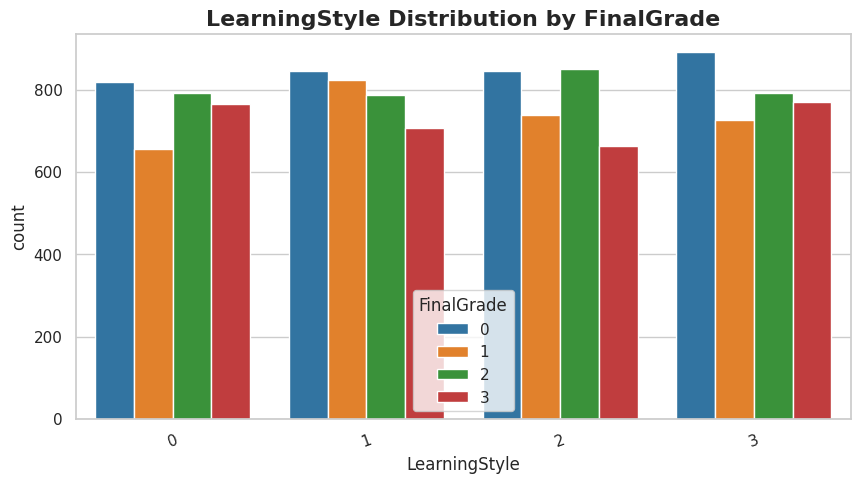

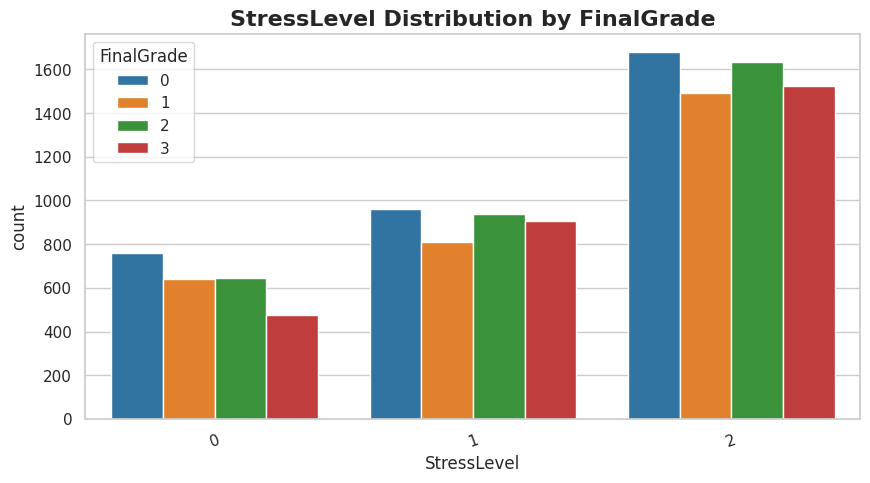

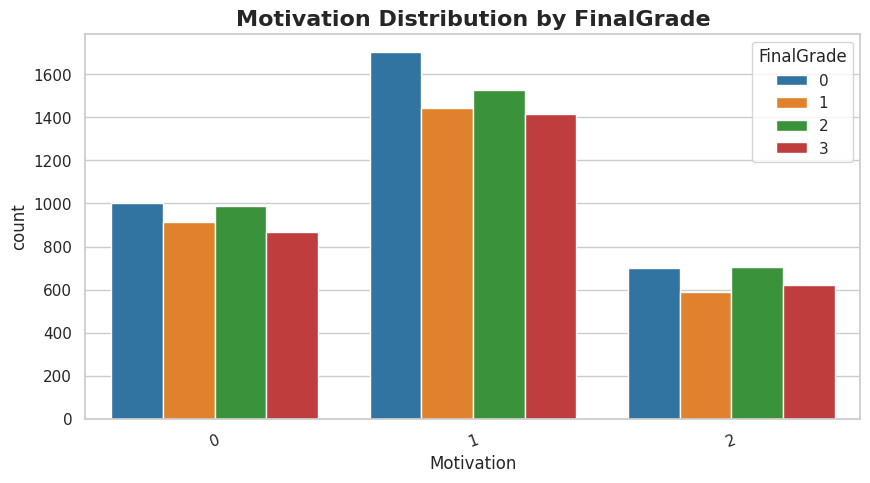

In [13]:
for col in categorical_features:

    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=df,
        x=col,
        hue=target,
        palette="tab10"
    )

    plt.title(
        f"{col} Distribution by FinalGrade",
        fontsize=16,
        fontweight="bold"
    )

    plt.xticks(rotation=20)
    plt.legend(title="FinalGrade")

    plt.show()

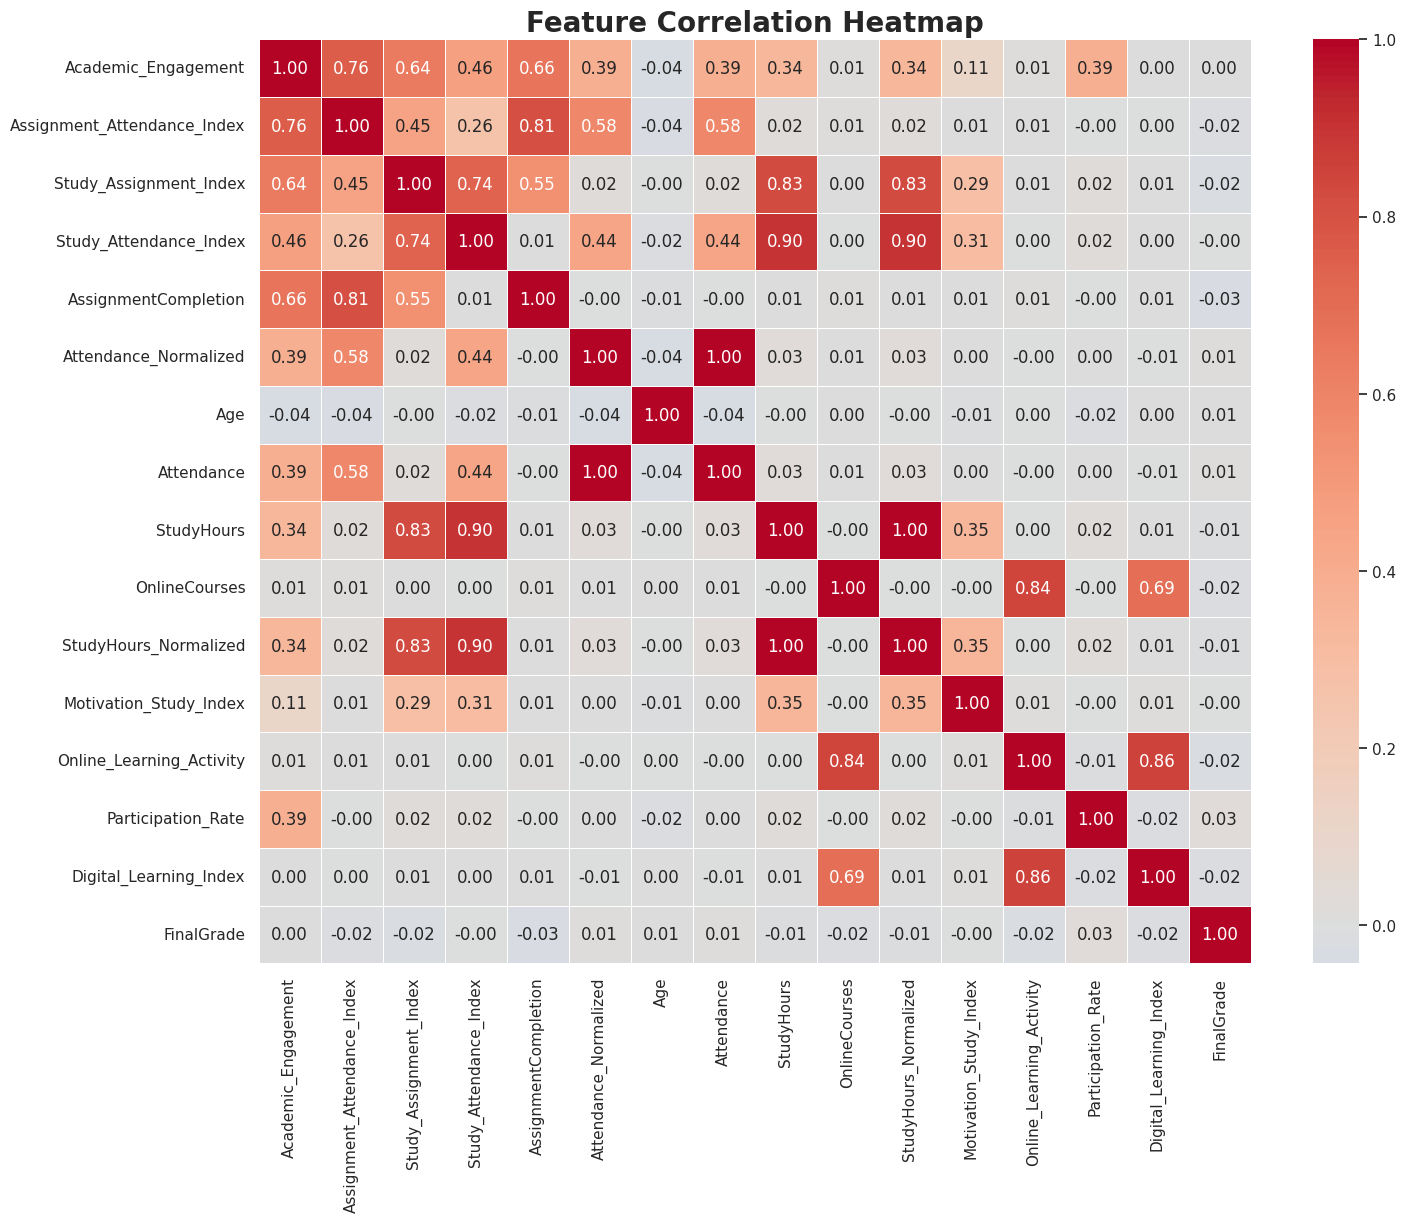

In [14]:
plt.figure(figsize=(16, 12))

correlation = df[numerical_features + [target]].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=20,
    fontweight="bold"
)

plt.show()

In [15]:
corr = df[numerical_features + [target]].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    title="Interactive Feature Correlation Matrix"
)

fig.update_layout(
    width=1100,
    height=800
)

fig.show()

In [16]:
fig = px.scatter_3d(
    df.sample(min(4000, len(df)), random_state=42),
    x="Attendance",
    y="StudyHours",
    z="Academic_Engagement",
    color="FinalGrade",
    symbol="FinalGrade",
    opacity=0.75,
    title="3D Student Performance Space"
)

fig.update_layout(
    width=1100,
    height=800
)

fig.show()

In [17]:
fig = px.scatter_3d(
    df.sample(min(4000, len(df)), random_state=42),
    x="Attendance_Normalized",
    y="Study_Assignment_Index",
    z="Digital_Learning_Index",
    color="FinalGrade",
    size="Academic_Engagement",
    opacity=0.7,
    title="3D Learning Behavior Visualization"
)

fig.show()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("\nTraining Target Distribution:")
display(y_train.value_counts(normalize=True).sort_index())

print("\nTesting Target Distribution:")
display(y_test.value_counts(normalize=True).sort_index())

Training Shape: (9975, 18)
Testing Shape: (2494, 18)

Training Target Distribution:


,proportion
FinalGrade,
0,0.272782
1,0.235990
2,0.258346
3,0.232882



Testing Target Distribution:


,proportion
FinalGrade,
0,0.272654
1,0.236167
2,0.258220
3,0.232959


In [19]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessor created.")

Preprocessor created.


In [20]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ),

    "Ridge Classifier": RidgeClassifier(),

    "Linear SVM": LinearSVC(
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE
    ),

    "SVM RBF": SVC(
        kernel="rbf",
        probability=True,
        random_state=RANDOM_STATE
    ),

    "SVM Polynomial": SVC(
        kernel="poly",
        degree=3,
        probability=True,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=RANDOM_STATE
    ),

    "Bagging": BaggingClassifier(
        n_estimators=150,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        n_jobs=-1
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),

    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(
        reg_param=0.1
    ),

    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        max_iter=1000,
        early_stopping=True,
        random_state=RANDOM_STATE
    ),

    "LightGBM": LGBMClassifier(
        objective="multiclass",
        num_class=4,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    ),

    "CatBoost": CatBoostClassifier(
        loss_function="MultiClass",
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=False,
        random_seed=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=4,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

print("Total models:", len(models))

Total models: 20


In [21]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Pipelines created:", len(pipelines))

Pipelines created: 20


In [22]:
trained_models = {}
validation_results = []

for name, pipeline in pipelines.items():

    print(f"Training: {name}")

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    y_pred = pipeline.predict(X_test)

    validation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_Macro": precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall_Macro": recall_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1_Macro": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1_Weighted": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(validation_results)

results_df = results_df.sort_values(
    "F1_Macro",
    ascending=False
).reset_index(drop=True)

display(results_df)

Training: Logistic Regression
Training: Ridge Classifier
Training: Linear SVM
Training: SVM RBF
Training: SVM Polynomial
Training: Decision Tree
Training: Random Forest
Training: Extra Trees
Training: Gradient Boosting
Training: HistGradientBoosting
Training: AdaBoost
Training: Bagging
Training: KNN
Training: Gaussian Naive Bayes
Training: Linear Discriminant Analysis
Training: Quadratic Discriminant Analysis
Training: MLP Neural Network
Training: LightGBM
Training: CatBoost
Training: XGBoost


,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,F1_Weighted
0,Bagging,0.908180,0.908949,0.907580,0.908160,0.908202
1,Extra Trees,0.908180,0.908993,0.907511,0.908141,0.908210
2,Random Forest,0.906977,0.908175,0.906420,0.907140,0.907042
3,LightGBM,0.859663,0.861773,0.858984,0.859730,0.859666
4,Decision Tree,0.856856,0.856168,0.856734,0.856417,0.856864
5,XGBoost,0.827185,0.828649,0.825921,0.826582,0.826898
6,HistGradientBoosting,0.823577,0.825583,0.822250,0.823460,0.823589
7,MLP Neural Network,0.634322,0.633193,0.633101,0.632882,0.634262
8,CatBoost,0.595830,0.597504,0.590451,0.590081,0.592612
9,KNN,0.495188,0.501200,0.490560,0.490477,0.492212


In [23]:
leaderboard = results_df.copy()

leaderboard.index = np.arange(1, len(leaderboard) + 1)

display(
    leaderboard.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision_Macro": "{:.4f}",
        "Recall_Macro": "{:.4f}",
        "F1_Macro": "{:.4f}",
        "F1_Weighted": "{:.4f}"
    })
)

,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,F1_Weighted
1,Bagging,0.9082,0.9089,0.9076,0.9082,0.9082
2,Extra Trees,0.9082,0.9090,0.9075,0.9081,0.9082
3,Random Forest,0.9070,0.9082,0.9064,0.9071,0.9070
4,LightGBM,0.8597,0.8618,0.8590,0.8597,0.8597
5,Decision Tree,0.8569,0.8562,0.8567,0.8564,0.8569
6,XGBoost,0.8272,0.8286,0.8259,0.8266,0.8269
7,HistGradientBoosting,0.8236,0.8256,0.8222,0.8235,0.8236
8,MLP Neural Network,0.6343,0.6332,0.6331,0.6329,0.6343
9,CatBoost,0.5958,0.5975,0.5905,0.5901,0.5926
10,KNN,0.4952,0.5012,0.4906,0.4905,0.4922


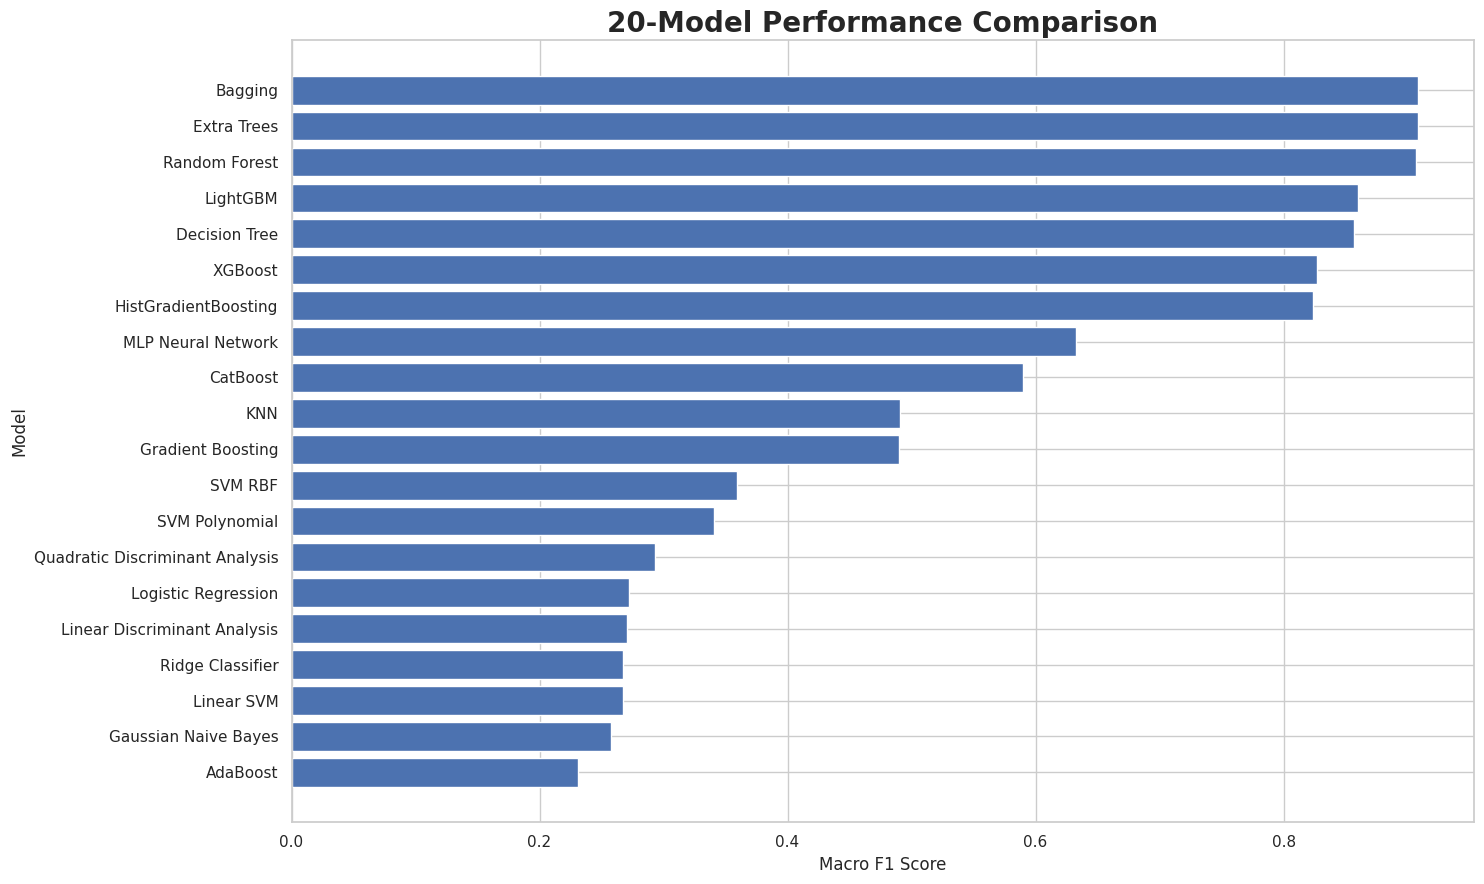

In [24]:
plt.figure(figsize=(15, 9))

plot_df = results_df.sort_values(
    "F1_Macro",
    ascending=True
)

plt.barh(
    plot_df["Model"],
    plot_df["F1_Macro"]
)

plt.xlabel("Macro F1 Score")
plt.ylabel("Model")
plt.title(
    "20-Model Performance Comparison",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [25]:
metrics_to_plot = [
    "Accuracy",
    "Precision_Macro",
    "Recall_Macro",
    "F1_Macro"
]

fig = go.Figure()

for metric in metrics_to_plot:

    fig.add_trace(
        go.Bar(
            x=results_df["Model"],
            y=results_df[metric],
            name=metric
        )
    )

fig.update_layout(
    title="20-Model Performance Comparison",
    xaxis_title="Model",
    yaxis_title="Score",
    barmode="group",
    height=800,
    xaxis_tickangle=-45
)

fig.show()

In [26]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

In [27]:
cv_results = []

for name, pipeline in pipelines.items():

    print(f"Cross-validating: {name}")

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision Macro": scores["test_precision_macro"].mean(),
        "CV Recall Macro": scores["test_recall_macro"].mean(),
        "CV F1 Macro": scores["test_f1_macro"].mean(),
        "CV F1 Weighted": scores["test_f1_weighted"].mean()
    })

cv_df = pd.DataFrame(cv_results)

cv_df = cv_df.sort_values(
    "CV F1 Macro",
    ascending=False
).reset_index(drop=True)

display(cv_df)

Cross-validating: Logistic Regression
Cross-validating: Ridge Classifier
Cross-validating: Linear SVM
Cross-validating: SVM RBF
Cross-validating: SVM Polynomial
Cross-validating: Decision Tree
Cross-validating: Random Forest
Cross-validating: Extra Trees
Cross-validating: Gradient Boosting
Cross-validating: HistGradientBoosting
Cross-validating: AdaBoost
Cross-validating: Bagging
Cross-validating: KNN
Cross-validating: Gaussian Naive Bayes
Cross-validating: Linear Discriminant Analysis
Cross-validating: Quadratic Discriminant Analysis
Cross-validating: MLP Neural Network
Cross-validating: LightGBM
Cross-validating: CatBoost
Cross-validating: XGBoost


,Model,CV Accuracy,CV Precision Macro,CV Recall Macro,CV F1 Macro,CV F1 Weighted
0,Extra Trees,0.863358,0.864412,0.862778,0.863300,0.863341
1,Bagging,0.862456,0.863496,0.861725,0.862336,0.862416
2,Random Forest,0.861053,0.862618,0.860165,0.861024,0.861011
3,Decision Tree,0.812932,0.812532,0.812754,0.812486,0.812931
4,LightGBM,0.803108,0.804863,0.801868,0.802863,0.803035
5,HistGradientBoosting,0.779950,0.781674,0.778566,0.779596,0.779892
6,XGBoost,0.778747,0.780531,0.777274,0.778327,0.778656
7,CatBoost,0.568421,0.576397,0.563649,0.564819,0.566375
8,MLP Neural Network,0.502556,0.502057,0.500164,0.500111,0.501653
9,Gradient Boosting,0.469173,0.474180,0.463346,0.462117,0.464668


In [28]:
display(
    cv_df.style.format({
        "CV Accuracy": "{:.4f}",
        "CV Precision Macro": "{:.4f}",
        "CV Recall Macro": "{:.4f}",
        "CV F1 Macro": "{:.4f}",
        "CV F1 Weighted": "{:.4f}"
    })
)

,Model,CV Accuracy,CV Precision Macro,CV Recall Macro,CV F1 Macro,CV F1 Weighted
0,Extra Trees,0.8634,0.8644,0.8628,0.8633,0.8633
1,Bagging,0.8625,0.8635,0.8617,0.8623,0.8624
2,Random Forest,0.8611,0.8626,0.8602,0.8610,0.8610
3,Decision Tree,0.8129,0.8125,0.8128,0.8125,0.8129
4,LightGBM,0.8031,0.8049,0.8019,0.8029,0.8030
5,HistGradientBoosting,0.7799,0.7817,0.7786,0.7796,0.7799
6,XGBoost,0.7787,0.7805,0.7773,0.7783,0.7787
7,CatBoost,0.5684,0.5764,0.5636,0.5648,0.5664
8,MLP Neural Network,0.5026,0.5021,0.5002,0.5001,0.5017
9,Gradient Boosting,0.4692,0.4742,0.4633,0.4621,0.4647


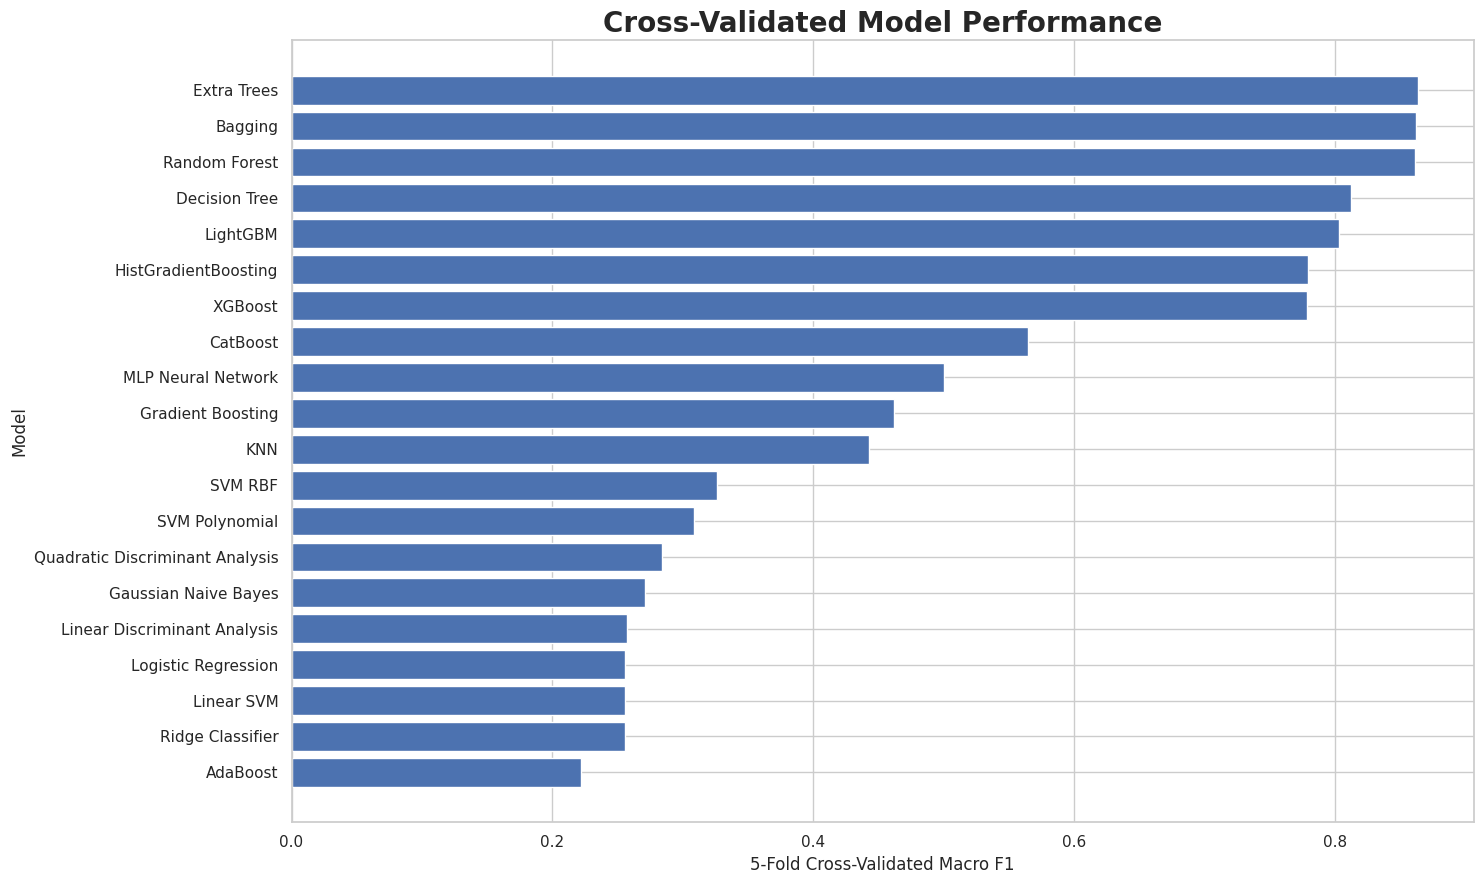

In [29]:
plt.figure(figsize=(15, 9))

plot_df = cv_df.sort_values(
    "CV F1 Macro",
    ascending=True
)

plt.barh(
    plot_df["Model"],
    plot_df["CV F1 Macro"]
)

plt.xlabel("5-Fold Cross-Validated Macro F1")
plt.ylabel("Model")

plt.title(
    "Cross-Validated Model Performance",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [31]:
top_models = cv_df.head(5)["Model"].tolist()

print("Top 5 models selected for GridSearchCV:")

for i, model in enumerate(top_models, 1):
    print(i, model)

Top 5 models selected for GridSearchCV:
1 Extra Trees
2 Bagging
3 Random Forest
4 Decision Tree
5 LightGBM


In [32]:
param_grids = {

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs"],
        "model__class_weight": [None, "balanced"]
    },

    "SVM RBF": {
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"],
        "model__kernel": ["rbf"]
    },

    "SVM Polynomial": {
        "model__C": [0.1, 1, 10],
        "model__degree": [2, 3],
        "model__gamma": ["scale", "auto"]
    },

    "Decision Tree": {
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5]
    },

    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__max_features": ["sqrt", "log2"]
    },

    "Extra Trees": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__max_features": ["sqrt", "log2"]
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 5]
    },

    "HistGradientBoosting": {
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_iter": [100, 200, 300],
        "model__max_leaf_nodes": [15, 31, 63]
    },

    "LightGBM": {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__num_leaves": [15, 31, 63],
        "model__max_depth": [-1, 5, 10],
        "model__subsample": [0.8, 1.0]
    },

    "CatBoost": {
        "model__iterations": [200, 400],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__depth": [4, 6, 8],
        "model__l2_leaf_reg": [1, 3, 5]
    },

    "XGBoost": {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }
}

In [33]:
grid_results = {}
grid_summary = []

for name in top_models:

    if name not in param_grids:
        print(f"No grid defined for {name}. Skipping.")
        continue

    print("\n" + "=" * 70)
    print("GRID SEARCH:", name)
    print("=" * 70)

    grid = GridSearchCV(
        estimator=pipelines[name],
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)

    grid_results[name] = grid

    grid_summary.append({
        "Model": name,
        "Best CV Macro F1": grid.best_score_,
        "Best Parameters": grid.best_params_
    })

grid_summary_df = pd.DataFrame(grid_summary)

display(grid_summary_df)


GRID SEARCH: Extra Trees
Fitting 5 folds for each of 24 candidates, totalling 120 fits
No grid defined for Bagging. Skipping.

GRID SEARCH: Random Forest
Fitting 5 folds for each of 24 candidates, totalling 120 fits

GRID SEARCH: Decision Tree
Fitting 5 folds for each of 36 candidates, totalling 180 fits

GRID SEARCH: LightGBM
Fitting 5 folds for each of 108 candidates, totalling 540 fits


,Model,Best CV Macro F1,Best Parameters
0,Extra Trees,0.863572,"{'model__max_depth': None, 'model__max_feature..."
1,Random Forest,0.861584,"{'model__max_depth': 20, 'model__max_features'..."
2,Decision Tree,0.812486,"{'model__max_depth': None, 'model__min_samples..."
3,LightGBM,0.859539,"{'model__learning_rate': 0.1, 'model__max_dept..."


In [34]:
best_grid_name = max(
    grid_results,
    key=lambda name: grid_results[name].best_score_
)

best_grid = grid_results[best_grid_name]

print("Best Tuned Model:")
print(best_grid_name)

print("\nBest CV Macro F1:")
print(best_grid.best_score_)

print("\nBest Parameters:")
print(best_grid.best_params_)

Best Tuned Model:
Extra Trees

Best CV Macro F1:
0.8635723044220154

Best Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [35]:
tuned_test_results = []

for name, grid in grid_results.items():

    y_pred = grid.predict(X_test)

    tuned_test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision Macro": precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall Macro": recall_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1 Macro": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1 Weighted": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )
    })

tuned_results_df = pd.DataFrame(tuned_test_results)

tuned_results_df = tuned_results_df.sort_values(
    "F1 Macro",
    ascending=False
)

display(tuned_results_df)

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,Random Forest,0.909383,0.910266,0.908964,0.909530,0.909415
0,Extra Trees,0.906977,0.908101,0.906247,0.907023,0.907000
3,LightGBM,0.903769,0.904536,0.903711,0.904066,0.903807
2,Decision Tree,0.856856,0.856168,0.856734,0.856417,0.856864


In [36]:
final_model = best_grid.best_estimator_

y_pred = final_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.8906    0.9221    0.9061       680
           1     0.8998    0.8846    0.8921       589
           2     0.9060    0.9130    0.9095       644
           3     0.9359    0.9053    0.9204       581

    accuracy                         0.9070      2494
   macro avg     0.9081    0.9062    0.9070      2494
weighted avg     0.9073    0.9070    0.9070      2494



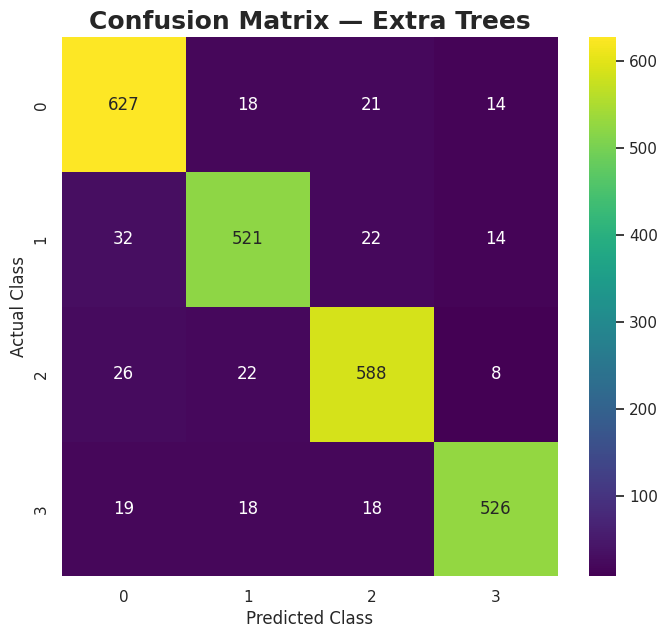

In [37]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    f"Confusion Matrix — {best_grid_name}",
    fontsize=18,
    fontweight="bold"
)

plt.show()

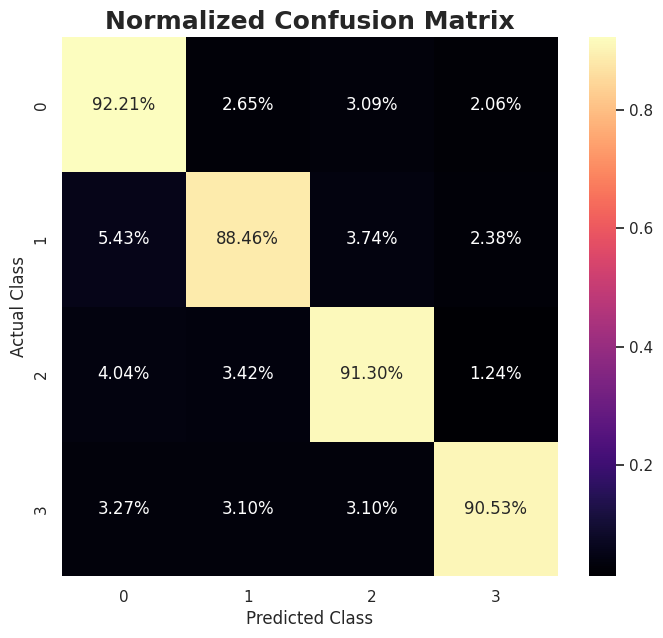

In [38]:
cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    normalize="true"
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="magma",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Normalized Confusion Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.show()

In [39]:
preprocessor_fitted = final_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

print("Total transformed features:", len(feature_names))

Total transformed features: 25


In [40]:
model_object = final_model.named_steps["model"]

if hasattr(model_object, "feature_importances_"):

    importance = model_object.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values(
        "Importance",
        ascending=False
    )

    display(feature_importance_df.head(25))

else:

    print(
        "The selected model does not expose "
        "feature_importances_."
    )

,Feature,Importance
4,num__AssignmentCompletion,0.074259
0,num__Academic_Engagement,0.074049
1,num__Assignment_Attendance_Index,0.073958
6,num__Age,0.073476
9,num__OnlineCourses,0.072686
7,num__Attendance,0.070502
5,num__Attendance_Normalized,0.069827
2,num__Study_Assignment_Index,0.068317
3,num__Study_Attendance_Index,0.066492
12,num__Online_Learning_Activity,0.062177


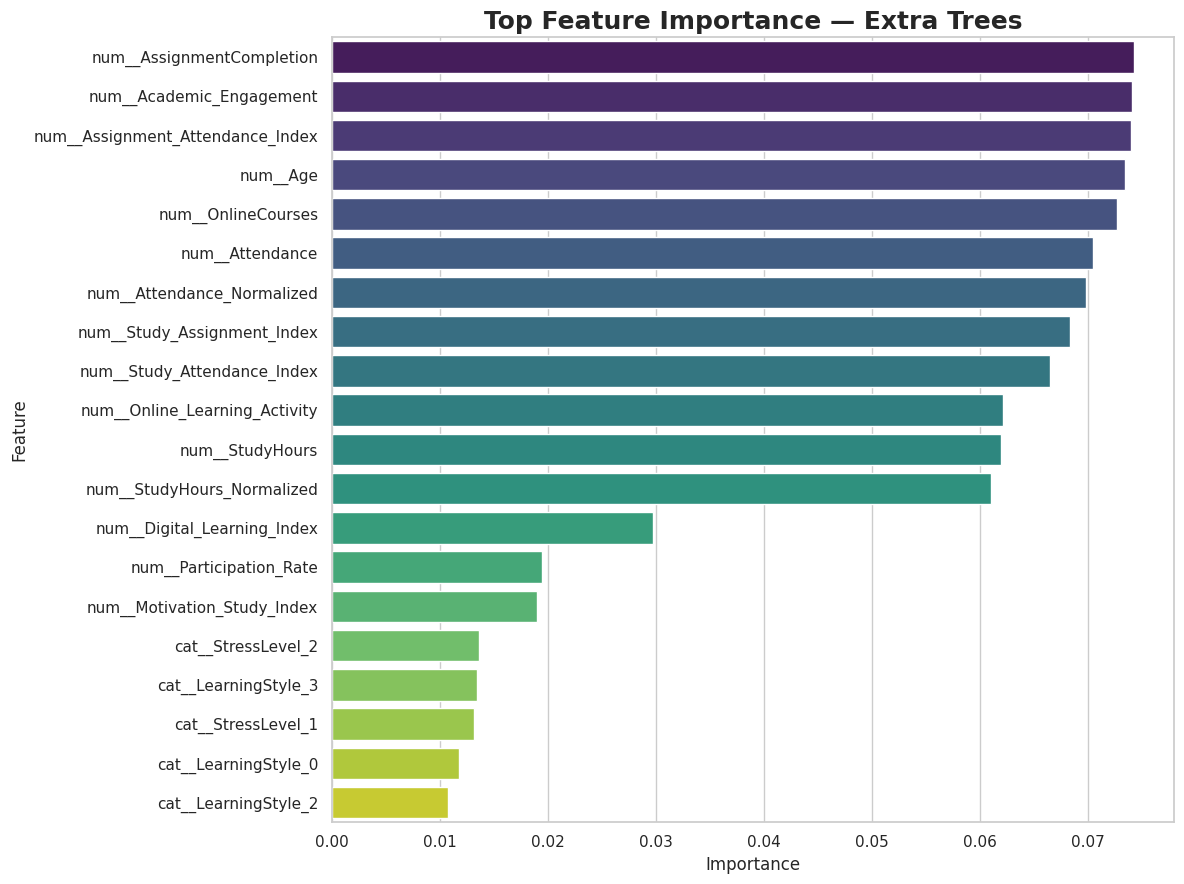

In [41]:
if hasattr(model_object, "feature_importances_"):

    top_features = feature_importance_df.head(20)

    plt.figure(figsize=(12, 9))

    sns.barplot(
        data=top_features,
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="viridis",
        legend=False
    )

    plt.title(
        f"Top Feature Importance — {best_grid_name}",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

In [42]:
permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation.importances_mean,
    "Std": permutation.importances_std
}).sort_values(
    "Importance",
    ascending=False
)

display(permutation_df)

,Feature,Importance,Std
11,LearningStyle,0.351991,0.012621
13,StressLevel,0.266622,0.005271
6,Age,0.022545,0.003288
5,Attendance_Normalized,0.009189,0.001676
9,OnlineCourses,0.008885,0.002371
14,Online_Learning_Activity,0.005839,0.001924
7,Attendance,0.005512,0.002467
4,AssignmentCompletion,0.003802,0.001909
1,Assignment_Attendance_Index,0.002982,0.001241
0,Academic_Engagement,0.002254,0.001879


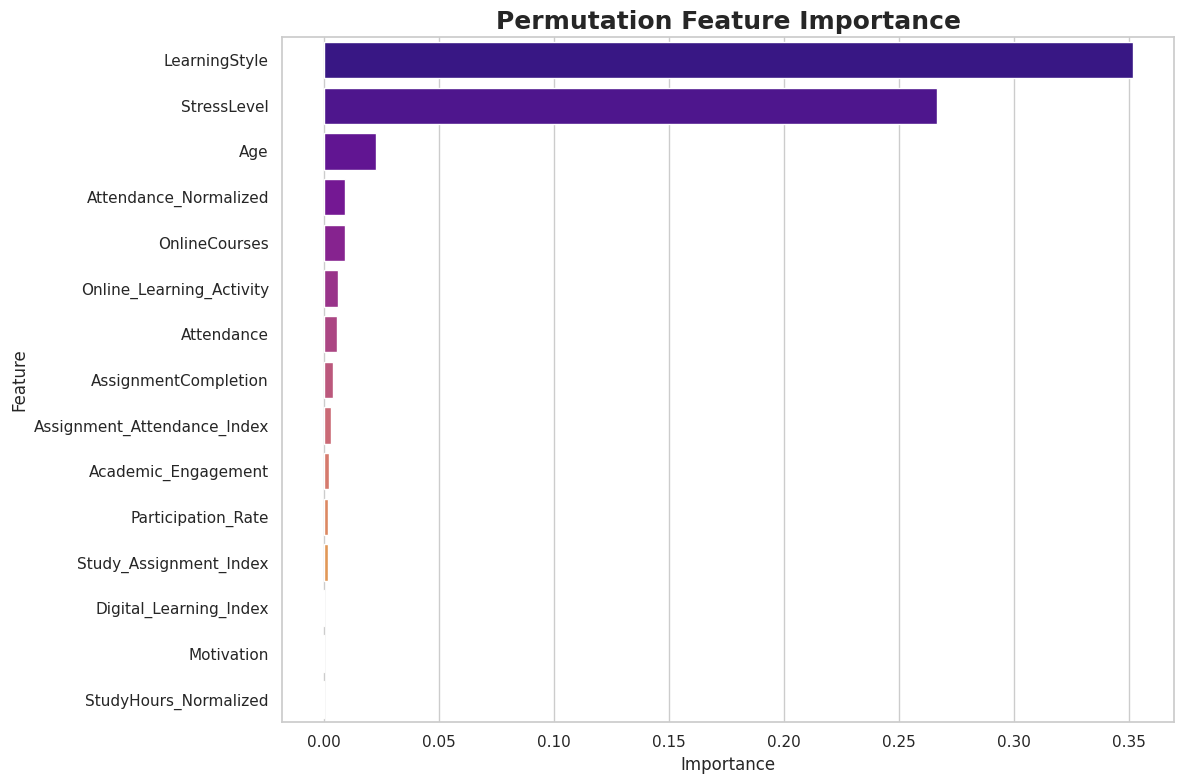

In [43]:
top_perm = permutation_df.head(15)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_perm,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="plasma",
    legend=False
)

plt.title(
    "Permutation Feature Importance",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [44]:
def predict_student(student_data, model=final_model):

    student_df = pd.DataFrame([student_data])

    predicted_class = model.predict(student_df)[0]

    if hasattr(model, "predict_proba"):

        probabilities = model.predict_proba(student_df)[0]

        probability_df = pd.DataFrame({
            "Class": model.classes_,
            "Probability": probabilities * 100
        })

        probability_df = probability_df.sort_values(
            "Probability",
            ascending=False
        ).reset_index(drop=True)

        confidence = probability_df.loc[
            0,
            "Probability"
        ]

        return predicted_class, probability_df, confidence

    return predicted_class, None, None

In [45]:
example_student = {
    "Academic_Engagement": 75,
    "Assignment_Attendance_Index": 80,
    "Study_Assignment_Index": 72,
    "Study_Attendance_Index": 78,
    "AssignmentCompletion": 85,
    "Attendance_Normalized": 0.85,
    "Age": 20,
    "Attendance": 85,
    "StudyHours": 4,
    "OnlineCourses": 3,
    "StudyHours_Normalized": 0.67,
    "LearningStyle": "Visual",
    "Motivation_Study_Index": 78,
    "StressLevel": "Low",
    "Online_Learning_Activity": 70,
    "Participation_Rate": 80,
    "Digital_Learning_Index": 75,
    "Motivation": "High"
}

predicted_class, probabilities, confidence = predict_student(
    example_student
)

print("Predicted FinalGrade Class:", predicted_class)

if probabilities is not None:

    print("\nClass Probabilities:")

    display(
        probabilities.style.format({
            "Probability": "{:.2f}%"
        })
    )

    print(
        f"\nPrediction Confidence: {confidence:.2f}%"
    )

Predicted FinalGrade Class: 0

Class Probabilities:


,Class,Probability
0,0,29.50%
1,1,26.50%
2,3,26.00%
3,2,18.00%



Prediction Confidence: 29.50%


In [46]:
# DO NOT invent these ranges.
# Replace them only when you know the official mapping
# between FinalGrade classes and percentage ranges.

class_to_percentage = {
    # 0: "YOUR RANGE",
    # 1: "YOUR RANGE",
    # 2: "YOUR RANGE",
    # 3: "YOUR RANGE"
}

if class_to_percentage:

    print(
        "Predicted class:",
        predicted_class
    )

    print(
        "Corresponding percentage range:",
        class_to_percentage.get(predicted_class)
    )

else:

    print(
        "Exact exam percentage cannot be reported "
        "from the current dataset."
    )

    print(
        "The model currently predicts FinalGrade class "
        "and class probabilities."
    )

Exact exam percentage cannot be reported from the current dataset.
The model currently predicts FinalGrade class and class probabilities.


In [47]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    final_model,
    "artifacts/edupredict_ai_final_model.pkl"
)

print(
    "Model saved successfully:"
    "\nartifacts/edupredict_ai_final_model.pkl"
)

Model saved successfully:
artifacts/edupredict_ai_final_model.pkl


In [48]:
results_df.to_csv(
    "artifacts/20_model_results.csv",
    index=False
)

cv_df.to_csv(
    "artifacts/20_model_cross_validation_results.csv",
    index=False
)

tuned_results_df.to_csv(
    "artifacts/tuned_model_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [49]:
if "feature_importance_df" in globals():

    feature_importance_df.to_csv(
        "artifacts/feature_importance.csv",
        index=False
    )

permutation_df.to_csv(
    "artifacts/permutation_importance.csv",
    index=False
)

print("Feature importance files saved.")

Feature importance files saved.


In [50]:
print("=" * 70)
print("EDUPREDICT AI — FINAL MODEL SUMMARY")
print("=" * 70)

print(f"\nDataset Size: {df.shape[0]:,} students")
print(f"Number of Features: {X.shape[1]}")
print(f"Number of Classes: {y.nunique()}")
print(f"Classes: {sorted(y.unique())}")

print(f"\n20 Models Evaluated")
print(f"Best Tuned Model: {best_grid_name}")

print(
    f"Best Cross-Validated Macro F1: "
    f"{best_grid.best_score_:.4f}"
)

print(
    f"Final Test Accuracy: "
    f"{accuracy_score(y_test, y_pred):.4f}"
)

print(
    f"Final Test Macro F1: "
    f"{f1_score(y_test, y_pred, average='macro'):.4f}"
)

print("\nModel artifact:")
print("artifacts/edupredict_ai_final_model.pkl")

print("=" * 70)

EDUPREDICT AI — FINAL MODEL SUMMARY

Dataset Size: 12,469 students
Number of Features: 18
Number of Classes: 4
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

20 Models Evaluated
Best Tuned Model: Extra Trees
Best Cross-Validated Macro F1: 0.8636
Final Test Accuracy: 0.9070
Final Test Macro F1: 0.9070

Model artifact:
artifacts/edupredict_ai_final_model.pkl
